# Lag Models

## This script accomplishes the following:

In this script, we will run 2 models, to predict the number of conflicts in each ZIP code, in each month.
The predictions are generated in a traditional ML way. We split the data into train and test sets, train the random forest on the former and  make the predicictions on the later.
Hence, we mask data that we "already saw", and then evaluate the models performance by taking the deviation from our predictions to the actual data.

## Find the following steps below:

1. **Random Forest Model**

- Define features and label (number of conflicts, for each ZIP in PA, for each month)
- Perform 4-fold time-series-cross-validation
- Split the data, using January - September for Train and October - December for Test
- Normalize the sets
- Define the rf regressor and fit
- Perform feature importance analysis
- Run a Grid Search to find the optimal parameter values
- Re-fit the model
- Make predictions
- Evaluation of Predictions

2. **XGBoost Model**

- Define the xgb regressor and fit
- Perform feature importance analysis
- Run a Grid Search to find the optimal parameter values
- Re-fit the model
- Make predictions
- Evaluation of Predictions

In [120]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from joblib import dump, load
import joblib
from sklearn.compose import ColumnTransformer

In [121]:
#Dynamic search path configuration
import sys
import os

#Adjusting search path based on notebook's depth in directory --> iterates through directories until it finds directory name: US_conflict_forecasting
current_dir = os.getcwd()
while 'US_conflict_forecasting' not in os.path.basename(current_dir):
    current_dir = os.path.dirname(current_dir)

#Adjusting search path based on 'new' current directory
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

from project_setup import setup_project
project_root_dir = setup_project()

### Load the data

In [122]:
# Load the data

data = pd.read_csv(os.path.join(project_root_dir, '2_Dataset/d_Final_Dataset/Final_Dataset_Lag_clean.csv'))


## 1. Random Forest

### Features and labels, cross-validation, split and normalization

In [123]:
train = data[data['month'] <= 9]

test = data[data['month'] > 9]

In [124]:

X_train = train.drop(['event_count', 'ZCTA', 'month'], axis=1)
Y_train = train['event_count']


X_test = test.drop(['event_count', 'ZCTA', 'month'], axis=1)
Y_test = test['event_count']


In [125]:
# Time Series Cross Validation, 4 folds.

tscv = TimeSeriesSplit(n_splits = 4)

In [126]:
# Scaling Process for the Train set

# Extract relative and absolute columns

relative_feature_ranges = [(28, 33), (35, 62), (64, 68), (70, 88), (90, 110), (115, 115), (118, 120)]
absolute_feature_ranges = [(0, 27), (34, 34), (63, 63), (69, 69), (89, 89), (111, 114), (116, 117), (121, 153)]

# Helper function to extract column names based on index ranges
def get_columns_by_index_ranges(data, ranges):
    columns = []
    for start, end in ranges:
        columns.extend(data.columns[start:end+1])
    return columns

# Extract columns
relative_columns_train = get_columns_by_index_ranges(X_train, relative_feature_ranges)
absolute_columns_train = get_columns_by_index_ranges(X_train, absolute_feature_ranges)

# Apply different scalers
preprocessor = ColumnTransformer(
    transformers=[
        ('abs', StandardScaler(), absolute_columns_train),
        ('rel', MinMaxScaler(), relative_columns_train)
    ])

In [127]:
# Scaling Process for the Test set

# Extract relative and absolute columns

relative_feature_ranges = [(28, 33), (35, 62), (64, 68), (70, 88), (90, 110), (115, 115), (118, 120)]
absolute_feature_ranges = [(0, 27), (34, 34), (63, 63), (69, 69), (89, 89), (111, 114), (116, 117), (121, 153)]

# Helper function to extract column names based on index ranges
def get_columns_by_index_ranges(data, ranges):
    columns = []
    for start, end in ranges:
        columns.extend(data.columns[start:end+1])
    return columns

# Extract columns
relative_columns_test = get_columns_by_index_ranges(X_test, relative_feature_ranges)
absolute_columns_test = get_columns_by_index_ranges(X_test, absolute_feature_ranges)

# ColumnTransformer to apply different scalers to different sets of features
preprocessor = ColumnTransformer(
    transformers=[
        ('abs', StandardScaler(), absolute_columns_test),
        ('rel', MinMaxScaler(), relative_columns_test)
    ])

In [128]:
# Apply the preporcessor to the data
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

### Define the regressor and run the model

In [130]:
rf_regressor = RandomForestRegressor(n_estimators = 100, random_state = 100)

In [131]:
rf_regressor.fit(X_train_scaled, Y_train)

RandomForestRegressor(random_state=100)

### Feature importance

In [132]:
# Which are the most important features?

feature_importances = rf_regressor.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]

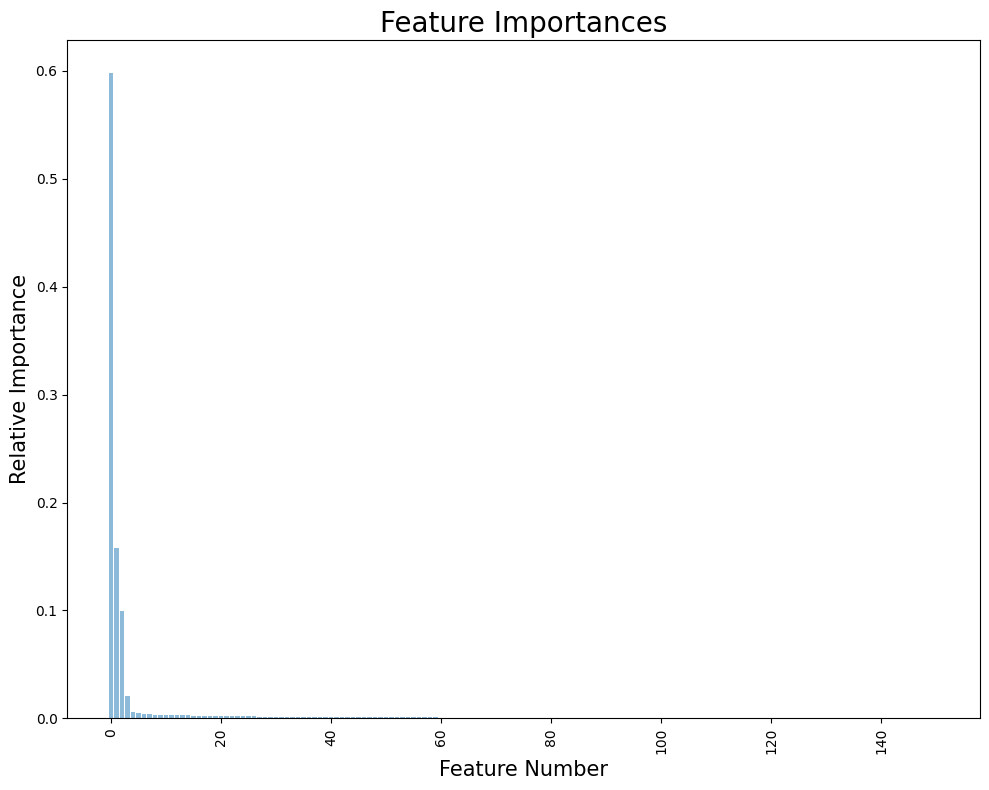

In [133]:
feature_importances = rf_regressor.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]

# Plot
plt.figure(figsize=(10, 8))
plt.title('Feature Importances', fontsize=20)
plt.bar(range(len(feature_importances)), feature_importances[sorted_indices], align='center', alpha=0.5)

num_features = len(feature_importances)
ticks = range(0, num_features, 20)
tick_labels = [str(i) for i in ticks]

plt.xticks(ticks, tick_labels, rotation=90)
plt.ylabel('Relative Importance', fontsize=15)
plt.xlabel('Feature Number', fontsize=15)
plt.tight_layout() 
plt.show()


### Extract most important feature names

In [134]:
# Extract the feature names

feature_names = X_train.columns

for i in range(20):
    print(f'{feature_names[sorted_indices[i]]}: {feature_importances[sorted_indices[i]]}')

event_count_prev_year: 0.5983995391160938
event_count_prev_month: 0.15747507025450455
set_peaceful_prot: 0.09951378092982667
fatalities: 0.021002970023910706
Bachelor's Degree or Higher, 2022: 0.005425539938025151
Foreign Born, Naturalized U.S. Citizen, 2022: 0.004992848096451736
act_oth: 0.0044852246212579
K-12 Grade Students Enrolled in Public School, 2022: 0.003632830132294368
set_other: 0.003106502541516676
Median Gross Rent, 2022: 0.0029254507903012806
topic2: 0.0028680113926959805
act_wor: 0.0028462009747166387
No High School Diploma, 2022: 0.0028187380287953982
Self-Employed, 2022: 0.0027342602892558936
High School Diploma or GED, 2022: 0.0026555442814207276
35 to 64 Years Old, 2022: 0.0026320724472692547
Native Born, 2022: 0.0025649153349817004
topic7: 0.002491476516580979
month_cos: 0.0023799091409377857
Flip22_ReptoDem_Senate: 0.002233682988210471


### Run Grid Search to find the best parameters

In [135]:
# Grid Search for best parameters

# Adjust number of trees in forest, max depth of trees, and minimum samples per leaf

# n_estimators: Number of trees in the forest, to take into account for the prediction
# max_depth: Maximum depth of the tree. From root to leaf, basically controls complexity of the tree and can lead/prevent overfitting. The more splits, the more complex the tree and the more likely to fit noise.
# min_samples_split: Minimum number of samples required to split an internal node


# Prevents overfitting and improves the generalization of the model

param_grid_rf = {
    'n_estimators': [100, 200, 400],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 7]
}

In [136]:
cv_rf = GridSearchCV(estimator=rf_regressor, param_grid=param_grid_rf, cv = tscv, n_jobs=-1)
cv_rf.fit(X_train_scaled, Y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=4, test_size=None),
             estimator=RandomForestRegressor(random_state=100), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30, 40],
                         'min_samples_split': [2, 5, 7],
                         'n_estimators': [100, 200, 400]})

### Re-run feature importance analysis

In [137]:
importances_gs = cv_rf.best_estimator_.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances_gs
}).sort_values(by='importance', ascending=False)
print(feature_importance_df)

                                              feature  importance
21                              event_count_prev_year    0.628462
22                             event_count_prev_month    0.163888
10                                  set_peaceful_prot    0.105018
0                                          fatalities    0.018147
11                                          set_other    0.003364
..                                                ...         ...
61              Households with Internet Access, 2022    0.000000
62           Households with No Internet Access, 2022    0.000000
65  Single Parents (No Spouse) with Children (<18)...    0.000000
14                                   set_violent_prot    0.000000
93           Children (<18) Below Poverty Level, 2022    0.000000

[151 rows x 2 columns]


### Plot again

In [138]:
feature_importance_df['feature_num'] = range(1, len(feature_importance_df) + 1)

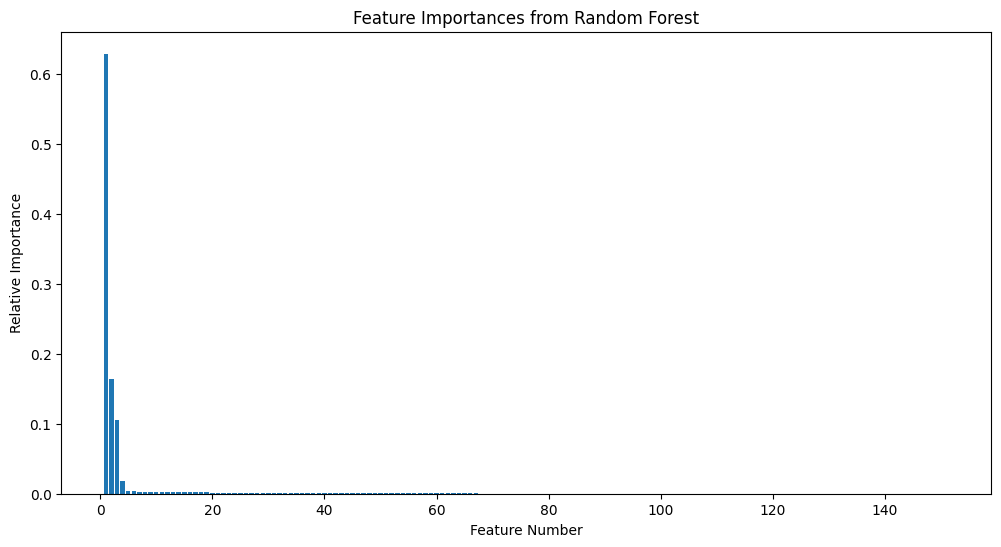

In [139]:
plt.figure(figsize=(12, 6))
plt.bar(feature_importance_df['feature_num'], feature_importance_df['importance'])
plt.xlabel('Feature Number')
plt.ylabel('Relative Importance')
plt.title('Feature Importances from Random Forest')
plt.show()

### Feature importance stll very similar after runnin with best parameters

## Run the predictions

### Without Best Parameters

In [140]:
Y_pred_rf = rf_regressor.predict(X_test_scaled)

predictions_rf = pd.DataFrame({'Actual': Y_test, 'Predicted': Y_pred_rf})
print(Y_pred_rf)

[0. 0. 0. ... 0. 0. 0.]


In [141]:
mse_rf = mean_squared_error(Y_test, Y_pred_rf)

print('Mean Squared Error:', mse_rf)

Mean Squared Error: 0.08754926350245498


### Including the Best Parameters

In [142]:
Y_pred_gs = cv_rf.predict(X_test_scaled)

predictions_gs = pd.DataFrame({'Actual': Y_test, 'Predicted': Y_pred_gs})
print(Y_pred_gs)

[0. 0. 0. ... 0. 0. 0.]


In [143]:
mse_gs = mean_squared_error(Y_test, Y_pred_gs)

print('Mean Squared Error:', mse_gs)

Mean Squared Error: 0.07866304740138438


## Save predictions

In [144]:
# Get ZIP code and month for each prediction
ZIP_results_rf = pd.merge(predictions_rf, data[['ZCTA', 'month']], left_index=True, right_index=True)

# Include all instances in which the model predicted a positive number of events
ZIP_results_rf = ZIP_results_rf[ZIP_results_rf['Predicted'] > 0]


# XGBoost Model


### Initialize and fit the XGBoost Regressor

In [145]:
xgb = XGBRegressor(use_label_encoder = False, eval_metric = 'logloss', random_state = 1 )
xgb.fit(X_train_scaled, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='logloss',
             feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, random_state=1, ...)

### Run Grid Search to find the best parameters:

In [146]:
param_grid_1 = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_child_weight': [1, 2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8]
}

In [147]:
# Progress function
def progress_printout(n_completed, n_tasks, *args, **kwargs):
    if n_completed % 10 == 0:
        print(f"{n_completed}/{n_tasks} fits completed")

In [148]:
# Set up a custom progress printout for joblib
with joblib.parallel.parallel_backend('threading', n_jobs=-1):
    joblib.parallel.parallel_printout = progress_printout

# Initialize XGB and GridSearch
# Include n_jobs = -1 to use all available cores
grid_search = GridSearchCV(estimator = xgb, param_grid = param_grid_1, scoring='neg_mean_squared_error', cv = tscv, verbose=1, n_jobs = -1)
grid_search.fit(X_train_scaled, Y_train)

# Print the best parameters
best_params = grid_search.best_params_
print("Best parameters:", best_params)

Fitting 4 folds for each of 1440 candidates, totalling 5760 fits
Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 100, 'subsample': 0.6}


### Re-run the model with optimal parameter values

In [149]:
# Re-train the model with the best parameters found above
xgb_optimized = XGBRegressor(**best_params, use_label_encoder=False, eval_metric='logloss', random_state = 1)
xgb_optimized.fit(X_train_scaled, Y_train)

# Make predictions
y_pred_optimized = xgb_optimized.predict(X_test_scaled)

### Run feature importance analysis

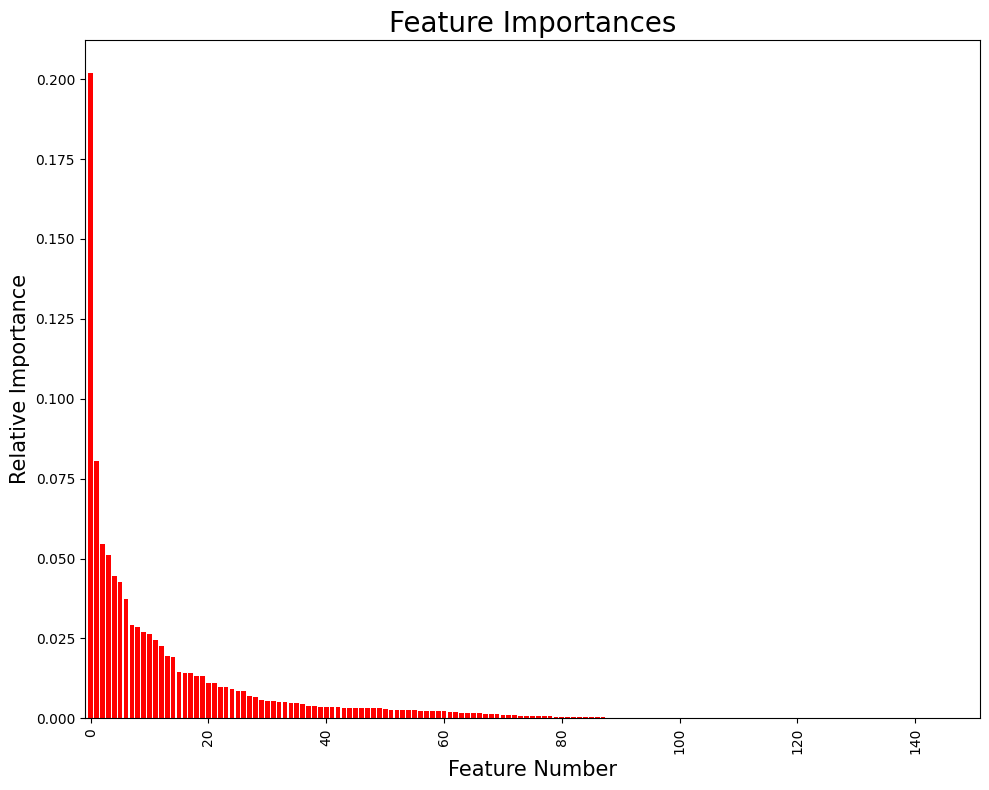

In [150]:
importances_xgb = xgb_optimized.feature_importances_
indices_xgb = np.argsort(importances_xgb)[::-1]

# Create the plot
plt.figure(figsize=(10, 8))
plt.title('Feature Importances', fontsize=20)
plt.bar(range(X_train.shape[1]), importances_xgb[indices_xgb], color='r', align='center')

# Show ticks from 0 and then every 20th feature
num_features = X_train.shape[1]
ticks = range(0, num_features, 20)
tick_labels = [str(i) for i in ticks]

plt.xticks(ticks, tick_labels, rotation=90)
plt.xlim([-1, num_features])
plt.ylabel('Relative Importance', fontsize=15)
plt.xlabel('Feature Number', fontsize=15)
plt.tight_layout()  # Adjusts the plot to ensure everything fits without overlapping
plt.show()


In [151]:
# Print the 10 most important features for the XGB model

for i in range(20):
    print(f'{X_train.columns[indices_xgb[i]]}: {importances_xgb[indices_xgb[i]]}')

event_count_prev_year: 0.20202873647212982
set_peaceful_prot: 0.0805547907948494
Median age : 0.054619722068309784
Bachelor's Degree or Higher, 2022: 0.051252711564302444
Renters (Renter-Occupied Units), 2022: 0.04455268383026123
fatalities: 0.04251982271671295
K-12 Grade Students Enrolled in School, 2022: 0.03725598007440567
K-12 Grade Students Enrolled in Private School, 2022: 0.029244285076856613
event_count_prev_month: 0.028627119958400726
topic1: 0.027084670960903168
Some College, No Degree, 2022: 0.026274988427758217
30% to 49% of Income for Rent, 2022: 0.02451646886765957
No High School Diploma, 2022: 0.022526515647768974
healthcare: 0.019476350396871567
Foreign Born, Naturalized U.S. Citizen, 2022: 0.019061677157878876
topic6: 0.014367538504302502
gun-violence: 0.01422717422246933
Shift_ReptoDem_20to22: 0.014041803777217865
months_until_election: 0.013312174007296562
act_rel: 0.013273512944579124


## Make the Predictions with the XGBoost Model

In [152]:
predictions_xgb = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred_optimized})

In [153]:
ZIP_results_xgb = pd.merge(predictions_xgb, data[['ZCTA', 'month']], left_index=True, right_index=True)

In [154]:
ZIP_results_xgb = ZIP_results_xgb[ZIP_results_xgb['Predicted'] > 0]

In [155]:
# Calculate MSE for XGBoost
mse_xgb = mean_squared_error(Y_test, y_pred_optimized)

print('Mean Squared Error:', mse_xgb)

Mean Squared Error: 0.09974071877214837


### Quick Linear Model as benchmark

In [156]:
# Calculate a linear model on the dataset

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, Y_train)

Y_pred_lr = lr.predict(X_test_scaled)

# MSE of linear regression model
mse_lr = mean_squared_error(Y_test, Y_pred_lr)

print('Mean Squared Error:', mse_lr)

Mean Squared Error: 1.584584183284742e+20


# Evaluation and Comparison of Lag models

In [157]:
# Print MSE of both models

print('Mean Squared Error Random Forest:', mse_gs)
print('Mean Squared Error XGBoost:', mse_xgb)
print('Mean Squared Error Linear Regression:', mse_lr)

Mean Squared Error Random Forest: 0.07866304740138438
Mean Squared Error XGBoost: 0.09974071877214837
Mean Squared Error Linear Regression: 1.584584183284742e+20


In [158]:
# Compare MSE of the models in a table

mse_comparison = pd.DataFrame({'Model': ['Random Forest', 'XGBoost', 'Linear Model'], 'MSE': [mse_gs, mse_xgb, mse_lr]})
print(mse_comparison)

           Model           MSE
0  Random Forest  7.866305e-02
1        XGBoost  9.974072e-02
2   Linear Model  1.584584e+20


In [159]:
# Compare the Root Mean Squared Error of the models

rmse_rf = np.sqrt(mse_gs)
rmse_xgb = np.sqrt(mse_xgb)
rmse_lr = np.sqrt(mse_lr)

rmse_comparison = pd.DataFrame({'Model': ['Random Forest', 'XGBoost', 'Linear Model'], 'RMSE': [rmse_rf, rmse_xgb, rmse_lr]})
print(rmse_comparison)

           Model          RMSE
0  Random Forest  2.804693e-01
1        XGBoost  3.158175e-01
2   Linear Model  1.258803e+10


In [160]:
# MSE and RMSE in one table

mse_rmse_comparison = pd.merge(mse_comparison, rmse_comparison, on='Model')
print(mse_rmse_comparison)

           Model           MSE          RMSE
0  Random Forest  7.866305e-02  2.804693e-01
1        XGBoost  9.974072e-02  3.158175e-01
2   Linear Model  1.584584e+20  1.258803e+10


In [161]:

# Show both models' predictions for ZIP codes with at least one conflict event in one table, so we can compare them side by side for each ZIP code

ZIP_results_comparison = pd.merge(ZIP_results_rf, ZIP_results_xgb, on=['ZCTA', 'month'], suffixes=('_rf', '_xgb'))
print(ZIP_results_comparison)

# Calculate the difference between the predicted values

ZIP_results_comparison['Difference'] = ZIP_results_comparison['Predicted_rf'] - ZIP_results_comparison['Predicted_xgb']

    Actual_rf  Predicted_rf     ZCTA  month  Actual_xgb  Predicted_xgb
0         1.0          1.49  15026.0   10.0         1.0       1.157593
1         1.0          1.53  15026.0   12.0         1.0       1.098570
2         1.0          1.83  15068.0   12.0         1.0       1.353343
3         1.0          1.60  15101.0   11.0         1.0       1.526159
4         1.0          1.25  15132.0   10.0         1.0       0.900687
5         1.0          1.26  15144.0   11.0         1.0       1.415244
6        21.0          8.48  15219.0   10.0        21.0       7.425852
7        20.0         17.29  15219.0   11.0        20.0      11.654328
8        16.0         13.56  15219.0   12.0        16.0       6.603560
9         1.0          1.28  15228.0   10.0         1.0       1.334886
10        1.0          0.46  15401.0   10.0         1.0       0.449106
11        1.0          1.34  16214.0   10.0         1.0       1.104869
12        2.0          2.92  16501.0   10.0         2.0       2.726954
13    